In [1]:
# Cell 1 - Install libraries
!pip install vaderSentiment pandas matplotlib wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.9 MB/s eta 0:00:00


In [2]:
# Cell 2 - Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

In [3]:
# Cell 3 - Load dataset
# We use a built-in sample dataset
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"
df = pd.read_csv(url)
df = df[['label', 'tweet']]
df.columns = ['sentiment', 'text']
print(df.head())
print(df.shape)

   sentiment                                               text
0          0   @user when a father is dysfunctional and is s...
1          0  @user @user thanks for #lyft credit i can't us...
2          0                                bihday your majesty
3          0  #model   i love u take with u all the time in ...
4          0             factsguide: society now    #motivation
(31962, 2)


In [4]:
# Cell 4 - Clean the text
import re
def clean_text(text):
    text = re.sub(r'http\S+', '', text)       # remove links
    text = re.sub(r'@\w+', '', text)           # remove mentions
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # remove special chars
    text = text.lower().strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
print(df.head())

   sentiment                                               text  \
0          0   @user when a father is dysfunctional and is s...   
1          0  @user @user thanks for #lyft credit i can't us...   
2          0                                bihday your majesty   
3          0  #model   i love u take with u all the time in ...   
4          0             factsguide: society now    #motivation   

                                          clean_text  
0  when a father is dysfunctional and is so selfi...  
1  thanks for lyft credit i cant use cause they d...  
2                                bihday your majesty  
3    model   i love u take with u all the time in ur  
4               factsguide society now    motivation  


In [5]:
# Cell 5 - Run Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['predicted_sentiment'] = df['clean_text'].apply(get_sentiment)
print(df['predicted_sentiment'].value_counts())

predicted_sentiment
Positive    16556
Neutral      8782
Negative     6624
Name: count, dtype: int64


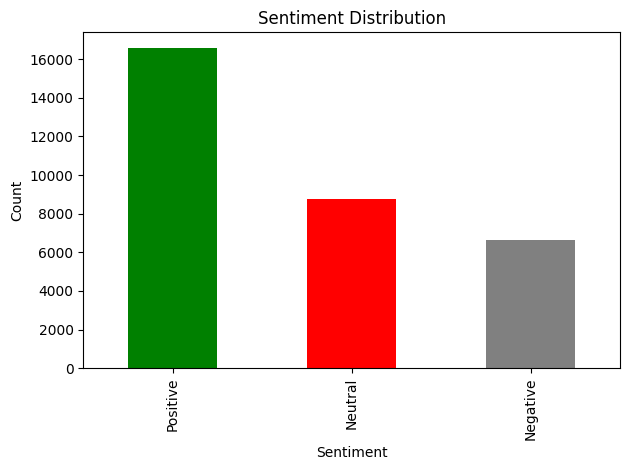

In [6]:
# Cell 6 - Visualize results
df['predicted_sentiment'].value_counts().plot(kind='bar', color=['green','red','gray'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('sentiment_chart.png')
plt.show()

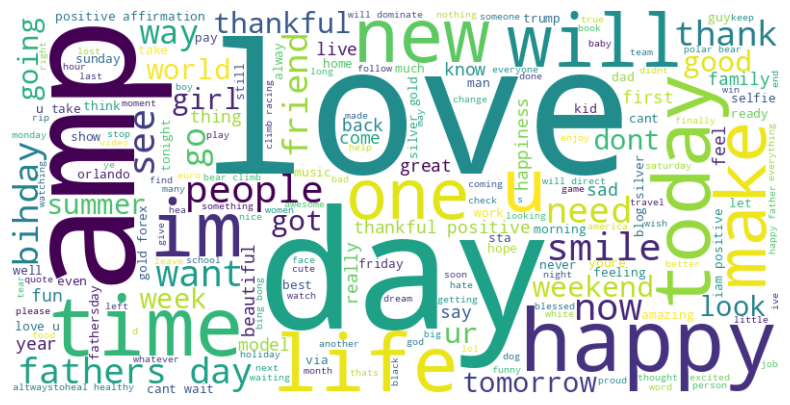

In [7]:
# Cell 7 - WordCloud
all_text = ' '.join(df['clean_text'].tolist())
wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.savefig('wordcloud.png')
plt.show()